## Import Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

## Load Dataset

In [2]:
df = pd.read_csv('heart_disease.csv')
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [3]:
df.shape

(920, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## Data Cleaning

In [6]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [7]:
# Handling Missing Values
df.drop(['ca', 'thal'], axis=1, inplace=True, errors='ignore')

In [9]:
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
cat_cols = ['fbs', 'restecg', 'exang', 'slope']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\sidda\AppData\Local\Temp\ipykernel_8420\1244649868.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [11]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

In [13]:
# Fixing Target Column
df.rename(columns={'num': 'target'}, inplace=True)

df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [14]:
# Convert sex dtype to 1/0
if df['sex'].dtype == 'object':
    df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

## Exploratory Data Analysis

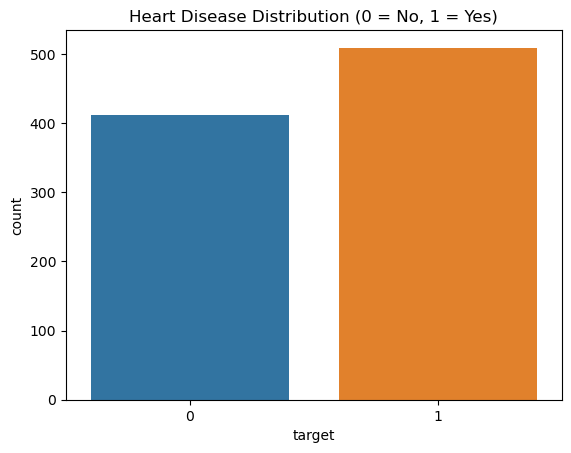

In [15]:
# Target Distribution
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution (0 = No, 1 = Yes)')
plt.show()

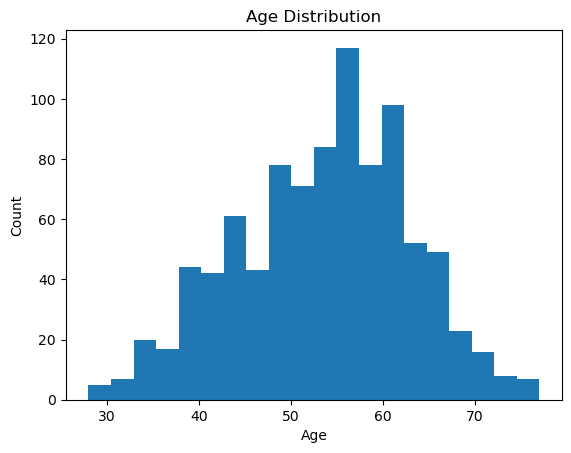

In [21]:
# Age Distribution
plt.hist(df['age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

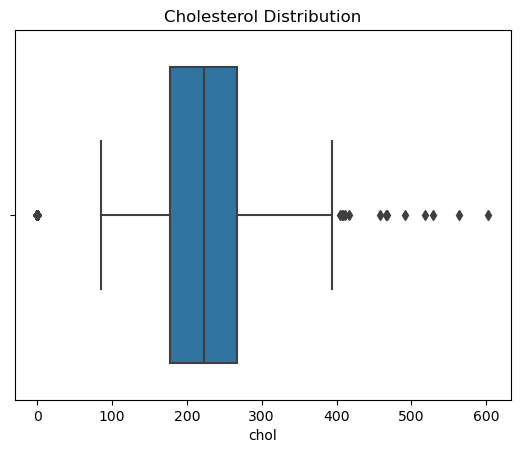

In [22]:
# Cholestrol Distribution
sns.boxplot(x=df['chol'])
plt.title('Cholesterol Distribution')
plt.show()

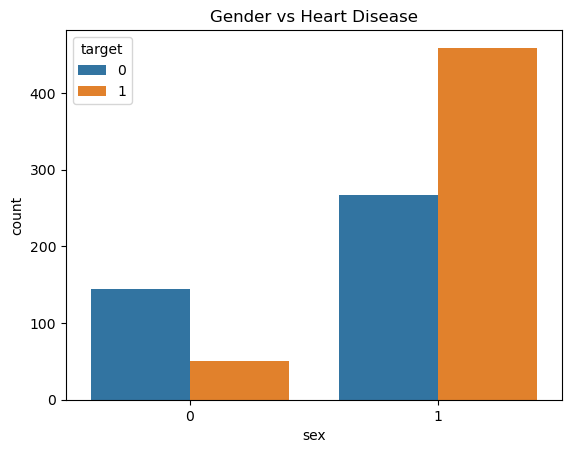

In [23]:
# Gender vs Heart Disease
sns.countplot(x='sex', hue='target', data=df)
plt.title('Gender vs Heart Disease')
plt.show()

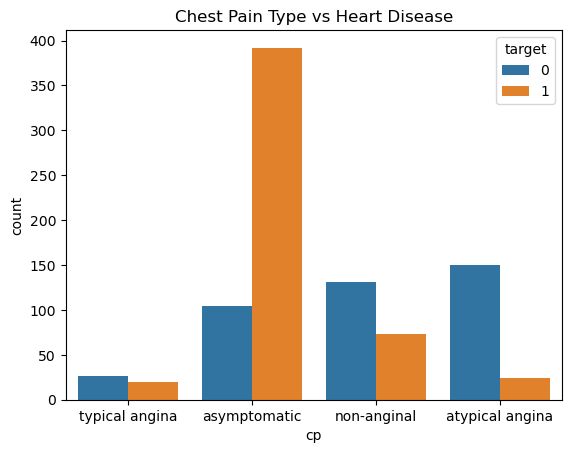

In [19]:
# Chestpain vs Target
sns.countplot(x='cp', hue='target', data=df)
plt.title('Chest Pain Type vs Heart Disease')
plt.show()

## Feature Analysis

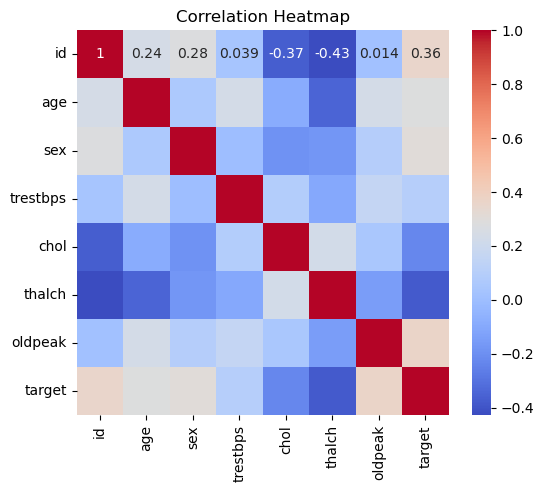

In [27]:
# Correlation Heatmap 
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [31]:
# Feature Importance
numeric_df.corr()['target'].sort_values(ascending=False)

target      1.000000
oldpeak     0.366138
id          0.356086
sex         0.307284
age         0.282700
trestbps    0.101273
chol       -0.228976
thalch     -0.381864
Name: target, dtype: float64

In [36]:
# Drop non-numeric columns
df = df.select_dtypes(include=['int64', 'float64'])

## Train Test Split

In [37]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [40]:
y_pred = model.predict(X_test)

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7717391304347826

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.79      0.74        75
           1       0.84      0.76      0.80       109

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.78      0.77      0.77       184



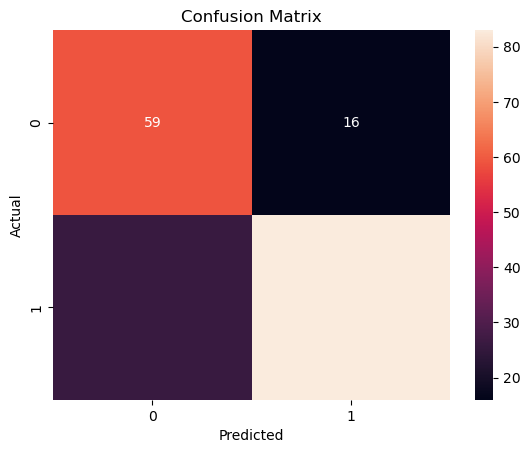

In [44]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Conclusion

This project analyzed patient health data to predict heart disease using machine learning.

The analysis showed that features such as age, cholesterol levels, and chest pain type have a strong influence on heart disease prediction. The Logistic Regression model performed well and was able to classify patients with good accuracy.

This demonstrates how data analytics and machine learning can assist in early detection of heart disease and support medical decision-making.